## Linear Regression Project
### Car Purchasing CSV Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../dataset/car_purchasing.csv',encoding='latin1')
df.head()

,customer name,customer e-mail,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


In [3]:
df.shape

(500, 9)

## Drop Columns Customer Name, Customer e-mail
#### Keeping Country : Different country have different prices in cars
#### Keeping Gender : Different gender would select different types of cars which affects the price
#### Keeping Age : Different Ages would select different types of cars which affects the price

In [4]:
df.columns

Index(['customer name', 'customer e-mail', 'country', 'gender', 'age',
       'annual Salary', 'credit card debt', 'net worth',
       'car purchase amount'],
      dtype='str')

In [5]:
df1 = df.drop(['customer name', 'customer e-mail'], axis='columns')
df1.head()

,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Bulgaria,0,41.851720,62812.09301,11609.380910,238961.2505,35321.45877
1,Belize,0,40.870623,66646.89292,9572.957136,530973.9078,45115.52566
2,Algeria,1,43.152897,53798.55112,11160.355060,638467.1773,42925.70921
3,Cook Islands,1,58.271369,79370.03798,14426.164850,548599.0524,67422.36313
4,Brazil,1,57.313749,59729.15130,5358.712177,560304.0671,55915.46248


#### Age should only be whole numbers format only


In [6]:
import math

In [7]:
df1['age'] = df1['age'].apply(lambda x: math.floor(x))
df1.head()

,country,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,Bulgaria,0,41,62812.09301,11609.380910,238961.2505,35321.45877
1,Belize,0,40,66646.89292,9572.957136,530973.9078,45115.52566
2,Algeria,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Cook Islands,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Brazil,1,57,59729.15130,5358.712177,560304.0671,55915.46248


#### Study the demographics of the dataset.
##### How many different types of country, gender are the dataset representing

In [8]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   country              500 non-null    str    
 1   gender               500 non-null    int64  
 2   age                  500 non-null    int64  
 3   annual Salary        500 non-null    float64
 4   credit card debt     500 non-null    float64
 5   net worth            500 non-null    float64
 6   car purchase amount  500 non-null    float64
dtypes: float64(4), int64(2), str(1)
memory usage: 27.5 KB


In [9]:
df1.describe()

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.506000,45.774000,62127.239608,9607.645049,431475.713625,44209.799218
std,0.500465,7.988652,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,40.000000,54391.977195,7397.515792,299824.195900,37629.896040
50%,1.000000,46.000000,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,51.000000,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


#### On average values
##### Credit Card Debth: 9607.645049 ($9.6k)
##### Net Worth: 431475.713625	($431k)
##### Car Purchase Amount: 44209.799218 ($44.2k)

#### Gender 0 : Female
#### Gender 1 : Male

#### Checking if country column is required. If the demographic is sparsed using One-Hot Encoding, it wont be beneficial for the prediction of the model.

In [10]:
df1['country'].value_counts()

country
Bolivia                                         6
Israel                                          6
Mauritania                                      6
Algeria                                         5
Armenia                                         5
                                               ..
Ukraine                                         1
New Zealand                                     1
Saint Helena, Ascension and Tristan da Cunha    1
Malaysia                                        1
marlal                                          1
Name: count, Length: 211, dtype: int64

In [11]:
df1['gender'].value_counts()

gender
1    253
0    247
Name: count, dtype: int64

### Country Feature

- There are 211 unique countries in the dataset.

- The dataset contains only 500 samples.

- Most countries have very few observations (maximum of 6 samples).

- One-hot encoding would introduce ~210 sparse features and likely lead to overfitting.

- Therefore, the `Country` feature was removed.

In [12]:
df2 = df1.drop(['country'], axis='columns')
df2.head()

,gender,age,annual Salary,credit card debt,net worth,car purchase amount
0,0,41,62812.09301,11609.380910,238961.2505,35321.45877
1,0,40,66646.89292,9572.957136,530973.9078,45115.52566
2,1,43,53798.55112,11160.355060,638467.1773,42925.70921
3,1,58,79370.03798,14426.164850,548599.0524,67422.36313
4,1,57,59729.15130,5358.712177,560304.0671,55915.46248


In [13]:
df2.shape

(500, 6)

## Splitting Data into Test and Training dataset

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
features = df2[['gender', 'age', 'annual Salary', 'credit card debt', 'net worth']]
target = df2['car purchase amount']

In [16]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size = 0.2,random_state = 1)
print(f'x_train Shape: {x_train.shape} | x_train Dimensions: {x_train.ndim}')
print(f'x_test Shape: {x_test.shape} | x_test Dimensions: {x_test.ndim}')
print(f'y_train Shape: {y_train.shape} | y_train Dimensions: {y_train.ndim}')
print(f'y_test Shape: {y_test.shape} | y_test Dimensions: {y_test.ndim}')

x_train Shape: (400, 5) | x_train Dimensions: 2
x_test Shape: (100, 5) | x_test Dimensions: 2
y_train Shape: (400,) | y_train Dimensions: 1
y_test Shape: (100,) | y_test Dimensions: 1


#### Start prediction using Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [18]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [19]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ -10.21,6704.2 ,6391.55, -23.89,4952.96]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.428e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](5,)","[20.76,20.61,19.95,19.66,18.96]"


#### Obtaining the coefficients of the Line of Best Fit (y = w1x1 + w2x2 + w3x3 + w4x4 + w5x5 + b)
- y: car purchase amount (Independant Variable)
- W = [w1, w2, w3, w4, w5]: Corresponding weights for each feature (Gradient/Weights)
- X: [x1, x2, x3, x4, x5]: Corresponding features [x1: Gender, x2: Age, x3: Annual Salary, x4: Credit Card Debt, x5: Net Worth]
- b: y-intercept (Bias)

In [27]:
x_test.columns

Index(['gender', 'age', 'annual Salary', 'credit card debt', 'net worth'], dtype='str')

In [20]:
print(f'Coefficients [w1, w2, w3, w4, w5]: {model.coef_}')
print(f'Bias y-intercept: {model.intercept_}')

Coefficients [w1, w2, w3, w4, w5]: [ -10.21117964 6704.19529759 6391.5470227   -23.89355866 4952.95656567]
Bias y-intercept: 44277.4617845


#### Weights w2 (Weights for Age), w3 (Weights for Annual Salary) and w5 (Weights for Net Worth) are significant: 
- w2 at 6704.19529759
- w3 at 6391.5470227 
- w5 at 4952.95656567

By comparing standardized coefficients, age, annual salary and net worth were found to be the most influential predictors of car purchase amount. Gender and credit card debt contributed relatively little to the model. Since the features were standardized before training, coefficient magnitudes can be compared directly to assess relative influence.


#### Evaluation on model's performance on unseen data - Testing genaralisability

In [21]:
predictions = model.predict(x_test_scaled)
predictions_df = pd.DataFrame(predictions, columns = ['Predicted Car Purchase Amount'])
predictions_df.head()

,Predicted Car Purchase Amount
0,22159.503602
1,23819.890894
2,38147.091925
3,43497.693070
4,52978.601510


In [22]:
test_predictions = pd.concat([pd.DataFrame(predictions, columns = ['Predicted Car Purchase Amount']), y_test.reset_index(drop=True)], axis='columns')
test_predictions.head()

,Predicted Car Purchase Amount,car purchase amount
0,22159.503602,22091.11839
1,23819.890894,23517.91983
2,38147.091925,37843.46619
3,43497.693070,43680.91327
4,52978.601510,53110.88052


#### For evaluation of Linear Regression, we will use R2

- R2 --> 0: No correlation between the **Predicted Car Purchase Amount** and the **Actual Car Purchase Amount**
- R2 --> 1: Perfect correlation between the **Predicted Car Purchase Amount** and the **Actual Car Purchase Amount**

In [23]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [24]:
correlation_score = r2_score(y_test, predictions)
print(f'Correlation R-squared Score: {correlation_score}')
mse = mean_squared_error(y_test, predictions)
print(f'Mean Squared Error: {mse}')
mae = mean_absolute_error(y_test, predictions)
print(f'Mean Absolute Error: {mae}')

Correlation R-squared Score: 0.9995008012179929
Mean Squared Error: 61771.673562470154
Mean Absolute Error: 218.85233109477898


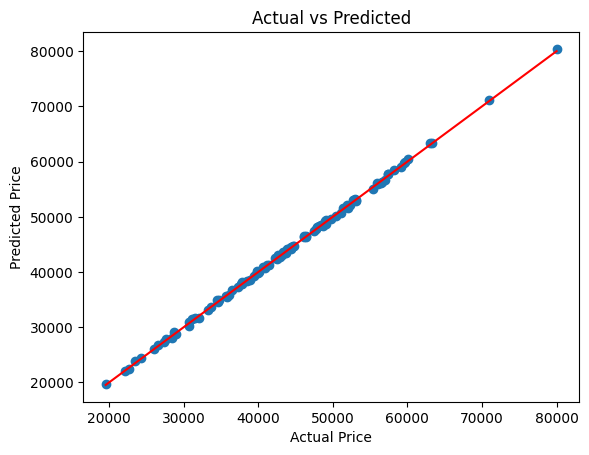

In [25]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r'
)

plt.show()